# 📈 Time Series Breakdown of Walmart Retail Sales

**Dataset:** `Walmart Sales Forecasting (Kaggle)`

**Tools Used:** `pandas`, `matplotlib`, `seaborn`

**Covered Topics:**

 - Time Series Analysis (monthly sales trends)

 - Trend & Seasonality

 - Revenue breakdown by product/region

 - **✅ Bonus:** Simple Forecasting (moving average & exponential smoothing)

## 1. 📥 Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Walmart.csv")
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 2. 🔎 Dataset Overview

In [3]:
df.info()
df.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Store,6435.0,NaN,NaN,NaN,23.0,12.988182,1.0,12.0,23.0,34.0,45.0
Date,6435,143,05-02-2010,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weekly_Sales,6435.0,NaN,NaN,NaN,1046964.877562,564366.622054,209986.25,553350.105,960746.04,1420158.66,3818686.45
Holiday_Flag,6435.0,NaN,NaN,NaN,0.06993,0.255049,0.0,0.0,0.0,0.0,1.0
Temperature,6435.0,NaN,NaN,NaN,60.663782,18.444933,-2.06,47.46,62.67,74.94,100.14
Fuel_Price,6435.0,NaN,NaN,NaN,3.358607,0.45902,2.472,2.933,3.445,3.735,4.468
CPI,6435.0,NaN,NaN,NaN,171.578394,39.356712,126.064,131.735,182.616521,212.743293,227.232807
Unemployment,6435.0,NaN,NaN,NaN,7.999151,1.875885,3.879,6.891,7.874,8.622,14.313


## 3. 📅 Convert Date & Aggregate Sales

In [7]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Monthly aggregation (use 'ME' instead of 'M')
monthly_sales = df.groupby(pd.Grouper(key='Date', freq='ME'))['Weekly_Sales'].sum().reset_index()

monthly_sales.head()




,Date,Weekly_Sales
0,2010-02-28,1.903330e+08
1,2010-03-31,1.819198e+08
2,2010-04-30,2.314124e+08
3,2010-05-31,1.867109e+08
4,2010-06-30,1.922462e+08


## 4. 📊 Time Series Visualization

### 4.1 Overall Monthly Sales Trend

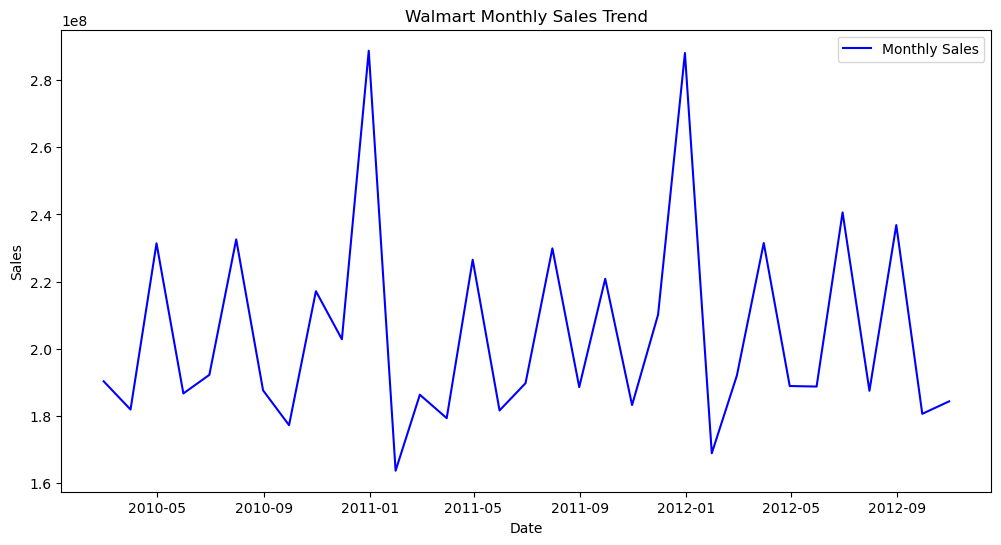

In [8]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Date'], monthly_sales['Weekly_Sales'], label="Monthly Sales", color="blue")
plt.title("Walmart Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


## 5. 📈 Trend & Seasonality

### 5.1 Rolling Mean (Moving Average)

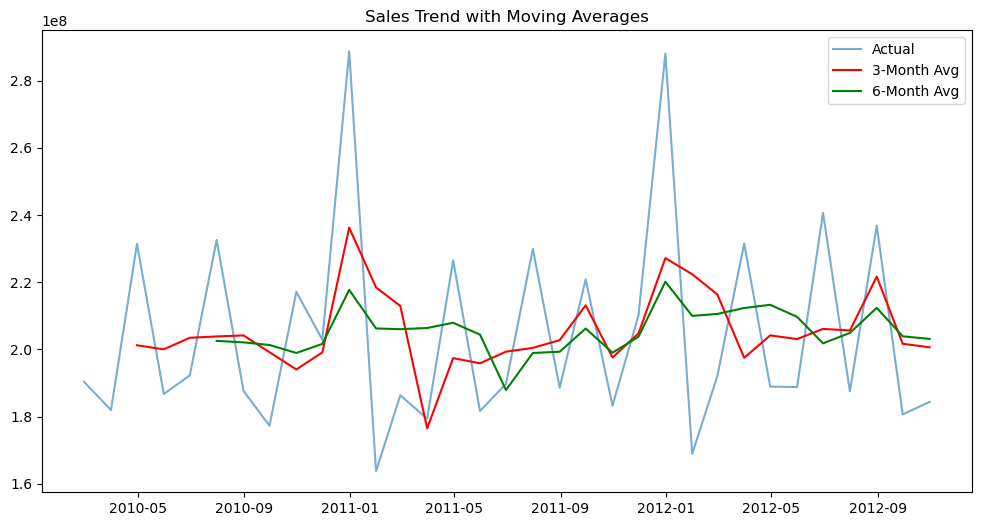

In [9]:
monthly_sales['Rolling_3'] = monthly_sales['Weekly_Sales'].rolling(window=3).mean()
monthly_sales['Rolling_6'] = monthly_sales['Weekly_Sales'].rolling(window=6).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Date'], monthly_sales['Weekly_Sales'], label="Actual", alpha=0.6)
plt.plot(monthly_sales['Date'], monthly_sales['Rolling_3'], label="3-Month Avg", color="red")
plt.plot(monthly_sales['Date'], monthly_sales['Rolling_6'], label="6-Month Avg", color="green")
plt.title("Sales Trend with Moving Averages")
plt.legend()
plt.show()


## 6. 🏬 Breakdown by Region & Product

### 6.1 Sales by Region (Over Time)

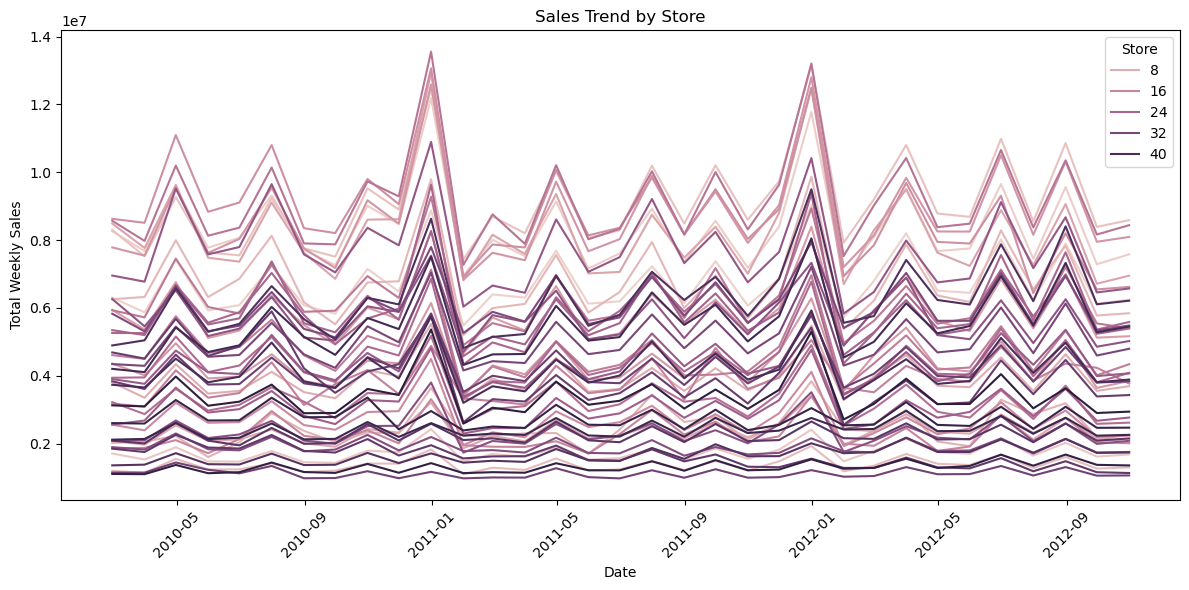

In [12]:
store_sales = df.groupby([pd.Grouper(key='Date', freq='ME'), 'Store'])['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x="Date", y="Weekly_Sales", hue="Store", data=store_sales)
plt.title("Sales Trend by Store")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### 6.2 Sales by Product/Department

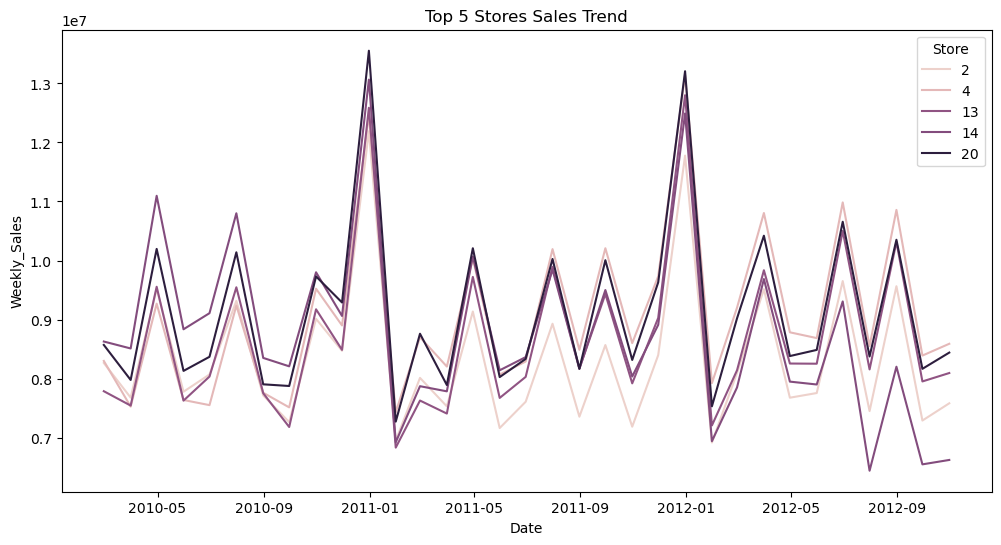

In [14]:
store_sales = df.groupby([pd.Grouper(key='Date', freq='ME'), 'Store'])['Weekly_Sales'].sum().reset_index()

top_stores = store_sales.groupby('Store')['Weekly_Sales'].sum().nlargest(5).index
top_store_sales = store_sales[store_sales['Store'].isin(top_stores)]

plt.figure(figsize=(12,6))
sns.lineplot(x="Date", y="Weekly_Sales", hue="Store", data=top_store_sales)
plt.title("Top 5 Stores Sales Trend")
plt.show()


## 7. 🔮 Bonus: Simple Forecasting

#### Exponential Smoothing

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


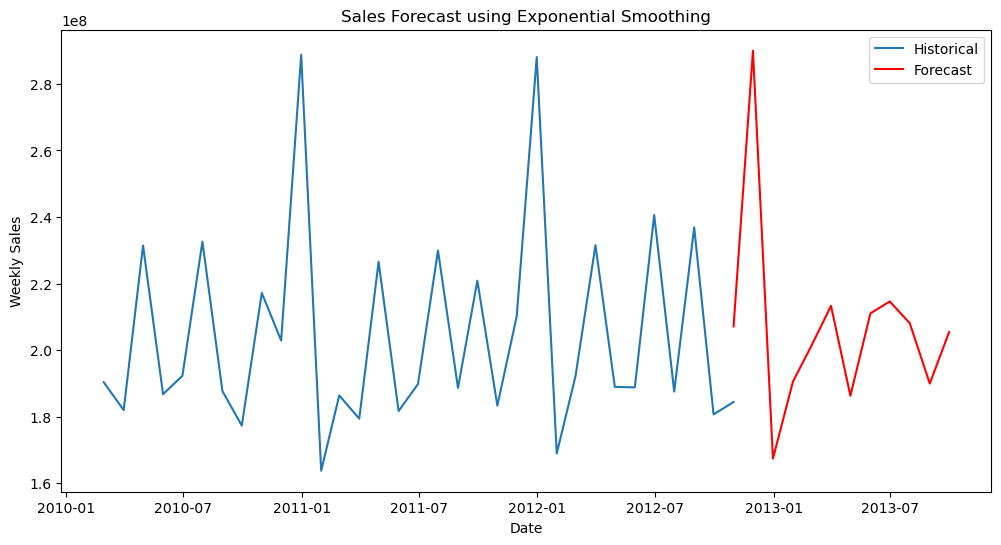

In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

# Ensure your 'Date' column is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate monthly sales
monthly_sales = df.groupby(pd.Grouper(key='Date', freq='ME'))['Weekly_Sales'].sum().reset_index()

# Fit Exponential Smoothing model (additive trend + seasonality)
model = ExponentialSmoothing(
    monthly_sales['Weekly_Sales'],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)
fit = model.fit()

# Forecast next 12 months
forecast = fit.forecast(12)

# Plot historical + forecast
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Date'], monthly_sales['Weekly_Sales'], label="Historical")
plt.plot(pd.date_range(monthly_sales['Date'].max(), periods=12, freq='ME'), forecast, label="Forecast", color="red")
plt.title("Sales Forecast using Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()
